In [57]:
import pandas as pd

df = pd.read_csv("Mumbai House Prices.csv")

print(df.shape)

(76038, 9)


In [58]:
df = df.drop_duplicates()

In [59]:
df["price_lakhs"] = df["price"].where(
    df["price_unit"] == "L",
    df["price"] * 100
)

In [60]:
df = df[df["age"] != "Unknown"]


In [61]:
df = df[df["area"].between(250, 10000)]

In [62]:
df = df[df["price_lakhs"].between(10, 2000)]

In [63]:
print(df.shape[0])

46976


In [64]:
print(df["price_lakhs"].median())

97.0


In [65]:
region_median = df.groupby("region")["price_lakhs"].agg(["count", "median"])

region_median = region_median[region_median["count"] >= 100]

print(region_median["median"].idxmax())

Worli


In [66]:
import matplotlib.pyplot as plt

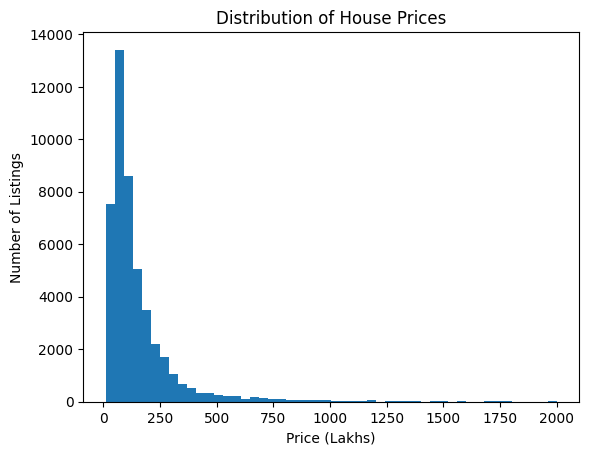

In [67]:
plt.hist(df["price_lakhs"], bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Listings")

plt.show()

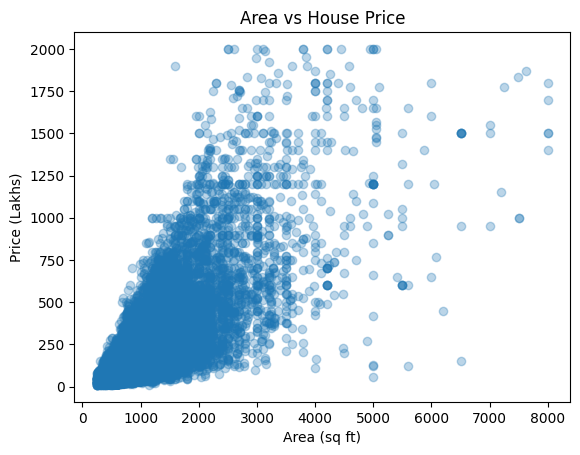

In [68]:
plt.scatter(df["area"], df["price_lakhs"], alpha=0.3)

plt.title("Area vs House Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (Lakhs)")

plt.show()

In [69]:
top_regions = df["region"].value_counts().head(15).index

top_region_medians = (
    df[df["region"].isin(top_regions)]
    .groupby("region")["price_lakhs"]
    .median()
    .sort_values()
)

print(top_region_medians)

region
Virar              37.000
Dombivali          50.000
Kalyan West        55.000
Panvel             75.000
Ulwe               76.000
Mira Road East     76.125
Thane West        108.000
Kharghar          125.000
Kandivali West    138.000
Kandivali East    158.000
Malad West        158.000
Chembur           178.000
Mulund West       186.500
Powai             249.000
Andheri West      270.000
Name: price_lakhs, dtype: float64


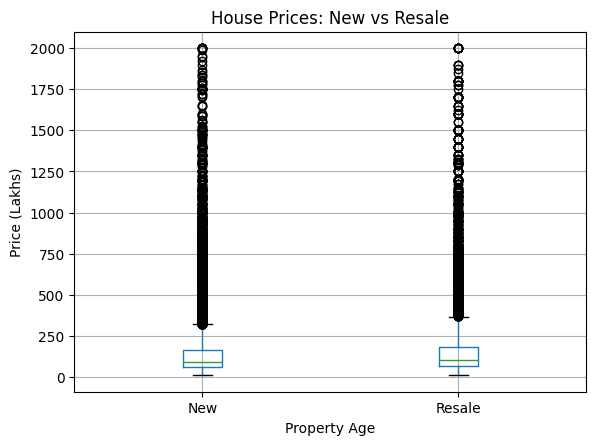

In [70]:
df.boxplot(column="price_lakhs", by="age")

plt.title("House Prices: New vs Resale")
plt.suptitle("")
plt.xlabel("Property Age")
plt.ylabel("Price (Lakhs)")

plt.show()

In [71]:
print(df["area"].corr(df["price_lakhs"]))

0.7354053544857129


In [72]:
print(df["price_lakhs"].skew())

4.242601786193739


In [73]:
print(df.groupby("age")["price_lakhs"].median())

age
New        93.45
Resale    106.00
Name: price_lakhs, dtype: float64


In [74]:
import numpy as np

In [75]:
log_price = np.log(df["price_lakhs"])

In [76]:
print("Original skewness:", df["price_lakhs"].skew())
print("Log-transformed skewness:", log_price.skew())

Original skewness: 4.242601786193739
Log-transformed skewness: 0.4152202085645013


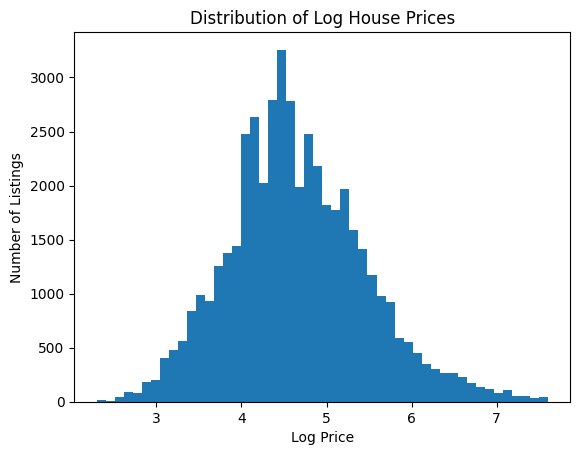

In [77]:
plt.hist(log_price, bins=50)

plt.title("Distribution of Log House Prices")
plt.xlabel("Log Price")
plt.ylabel("Number of Listings")

plt.show()

In [78]:
X = df[["bhk", "area", "type", "locality", "region", "status", "age"]]
y = np.log(df["price_lakhs"])

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [82]:
numeric_features = ["bhk", "area"]

categorical_features = ["type", "locality", "region", "status", "age"]

In [83]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [85]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [86]:
linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bhk', 'area']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type', 'locality', 'region',
                                                   'status', 'age'])])),
                ('model', LinearRegression())])

In [87]:
linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bhk', 'area']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type', 'locality', 'region',
                                                   'status', 'age'])])),
                ('model', LinearRegression())])

In [88]:
train_pred = linear_pipeline.predict(X_train)
test_pred = linear_pipeline.predict(X_test)


In [89]:
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Train R²:", train_r2)
print("Test R²:", test_r2)
print("Test RMSE:", test_rmse)

Train R²: 0.9771332431863284
Test R²: 0.9327722038582603
Test RMSE: 0.20905083140903544


In [90]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [91]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

In [92]:
ridge_grid = GridSearchCV(
    ridge_pipeline,
    {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5
)

In [93]:
ridge_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['bhk',
                                                                          'area']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['type',
                                                                          'locality',
                                                                          'region',
                                                                          'status',
                                                                          'age'])])),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

In [94]:
ridge_model = ridge_grid.best_estimator_

ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print("Best Ridge alpha:", ridge_grid.best_params_["model__alpha"])
print("Ridge Train R²:", ridge_train_r2)
print("Ridge Test R²:", ridge_test_r2)

Best Ridge alpha: 0.1
Ridge Train R²: 0.9765590237922723
Ridge Test R²: 0.9495212183374545


In [95]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

In [96]:
lasso_grid = GridSearchCV(
    lasso_pipeline,
    {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5
)

In [97]:
lasso_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['bhk',
                                                                          'area']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['type',
                                                                          'locality',
                                                                          'region',
                                                                          'status',
                                                                          'age'])])),
                                       ('model', Lasso(max_iter=10000))]),
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

In [98]:
print("Lasso grid ready:", lasso_grid)

Lasso grid ready: GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['bhk',
                                                                          'area']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['type',
                                                                          'locality',
                                                                          'region',
                                                                          'status',
                                          

In [99]:
lasso_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['bhk',
                                                                          'area']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['type',
                                                                          'locality',
                                                                          'region',
                                                                          'status',
                                                                          'age'])])),
                                       ('model', Lasso(max_iter=10000))]),
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

In [100]:
lasso_model = lasso_grid.best_estimator_

lasso_train_pred = lasso_model.predict(X_train)
lasso_test_pred = lasso_model.predict(X_test)

lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

zero_coeffs = (lasso_model.named_steps["model"].coef_ == 0).sum()

print("Best Lasso alpha:", lasso_grid.best_params_["model__alpha"])
print("Lasso Train R²:", lasso_train_r2)
print("Lasso Test R²:", lasso_test_r2)
print("Lasso zero coefficients:", zero_coeffs)

Best Lasso alpha: 0.001
Lasso Train R²: 0.8642541236240237
Lasso Test R²: 0.8677895318954394
Lasso zero coefficients: 7886


In [101]:
linear_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))

comparison = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "Train R²": [r2_score(y_train, train_pred),
                 ridge_train_r2,
                 lasso_train_r2],
    "Test R²": [r2_score(y_test, test_pred),
                ridge_test_r2,
                lasso_test_r2],
    "Test RMSE": [linear_rmse,
                  ridge_rmse,
                  lasso_rmse]
})

comparison

,Model,Train R²,Test R²,Test RMSE
0,Linear,0.977133,0.932772,0.209051
1,Ridge,0.976559,0.949521,0.181147
2,Lasso,0.864254,0.867790,0.293164


In [102]:
final_model = ridge_model

final_train_pred = final_model.predict(X_train)
final_test_pred = final_model.predict(X_test)

final_train_r2 = r2_score(y_train, final_train_pred)
final_test_r2 = r2_score(y_test, final_test_pred)

print("Final Model: Ridge")
print("Train R²:", final_train_r2)
print("Test R²:", final_test_r2)

Final Model: Ridge
Train R²: 0.9765590237922723
Test R²: 0.9495212183374545


In [103]:
final_preprocessor = final_model.named_steps["preprocessor"]
final_estimator = final_model.named_steps["model"]

feature_names = final_preprocessor.get_feature_names_out()
coefficients = final_estimator.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

coef_df.head(10)

,feature,coefficient,abs_coefficient
5013,cat__locality_Reputed Builder Rashmi,-2.220879,2.220879
5344,cat__locality_Reputed Builder Sunshine Apartment,-2.154519,2.154519
4478,cat__locality_Reputed Builder Gardenia,-2.142992,2.142992
4775,cat__locality_Reputed Builder Mansi Vihar,-2.101216,2.101216
773,cat__locality_Braj City,-2.097865,2.097865
5889,cat__locality_Sachiv Surinder Sahni The Legacy,-2.000255,2.000255
5286,cat__locality_Reputed Builder Silver Square,-1.735745,1.735745
5449,cat__locality_Reputed Builder Venus Apartment,-1.674429,1.674429
5006,cat__locality_Reputed Builder Rajani Gandha,-1.654002,1.654002
6239,cat__locality_Shalibhadra Shalibhadra Amora,-1.644804,1.644804


In [104]:
gap = final_train_r2 - final_test_r2

print("R² Gap:", gap)
print("Overfitting:", gap > 0.05)

R² Gap: 0.02703780545481782
Overfitting: False


In [105]:
# A1
A1 = len(df)

# A2
A2 = df["price_lakhs"].median()

# A3
region_median = df.groupby("region")["price_lakhs"].agg(["count", "median"])
region_median = region_median[region_median["count"] >= 100]
A3 = region_median["median"].idxmax()

# A4
A4 = df["area"].corr(df["price_lakhs"])

# A5
A5 = "Right-skewed"

# A6
A6 = df.groupby("age")["price_lakhs"].median().idxmax()

# A7
A7 = r2_score(y_test, test_pred)

# A8
A8_alpha = ridge_grid.best_params_["model__alpha"]
A8_r2 = ridge_test_r2

# A9
A9_alpha = lasso_grid.best_params_["model__alpha"]
A9_zero = zero_coeffs

# A10
A10 = "Ridge"

# A11
A11 = "locality"

# A12
A12 = "No"

print(f"A1: {A1}")
print(f"A2: {A2:.4f}")
print(f"A3: {A3}")
print(f"A4: {A4:.4f}")
print(f"A5: {A5}")
print(f"A6: {A6}")
print(f"A7: {A7:.4f}")
print(f"A8: {A8_alpha}, {A8_r2:.4f}")
print(f"A9: {A9_alpha}, {A9_zero}")
print(f"A10: {A10}")
print(f"A11: {A11}")
print(f"A12: {A12}")

A1: 46976
A2: 97.0000
A3: Worli
A4: 0.7354
A5: Right-skewed
A6: Resale
A7: 0.9328
A8: 0.1, 0.9495
A9: 0.001, 7886
A10: Ridge
A11: locality
A12: No
